# ECON 524 (Advanced Machine Learning) Final Project at Washington State University
### by Andrew Davila

My data comes from a Kaggle Competition called 'Natural Language Processing with Disaster Tweets'. We are given tweets that contain alarming lanaguage used in disasters and emergencies. The goal is to classify whether the tweets refers to a real disaster. 

In [62]:
#Importing necessary modules
import numpy as np
import pandas as pd
import os
import datetime
import math
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler 
import nltk
from nltk.corpus import stopwords
import string
import seaborn as sns
import spacy
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

The data provides only 5 columns, ID, Keywords, Location, and Target. 
- Tweet ID
- Keyword column that contains an 'alarming' word found within the tweets. For example if the tweet was 'The plane was caught in flames!', 'Flames' would be the keyword. 
- Location column that provides where the tweet was sent from 
- Target provides whether a disaster happened or not

- Minimal cleaning was done before loading. Train and test data sets were provided, and all empty cells were replaced with a word like 'None' or 'Unknown'.



## I. Loading Data

In [63]:
#Importing Data
df=pd.read_csv('train.csv')
print(df)

         id keyword location  \
0         1     NaN  Unknown   
1         4     NaN  Unknown   
2         5     NaN  Unknown   
3         6     NaN  Unknown   
4         7     NaN  Unknown   
...     ...     ...      ...   
7608  10869     NaN  Unknown   
7609  10870     NaN  Unknown   
7610  10871     NaN  Unknown   
7611  10872     NaN  Unknown   
7612  10873     NaN  Unknown   

                                                   text  target  
0     Our Deeds are the Reason of this #earthquake M...       1  
1                Forest fire near La Ronge Sask. Canada       1  
2     All residents asked to 'shelter in place' are ...       1  
3     13,000 people receive #wildfires evacuation or...       1  
4     Just got sent this photo from Ruby #Alaska as ...       1  
...                                                 ...     ...  
7608  Two giant cranes holding a bridge collapse int...       1  
7609  @aria_ahrary @TheTawniest The out of control w...       1  
7610  M1.94 [01:04 UT

We check to verify there are no missing values

In [64]:
df.isnull().sum()

id           0
keyword     61
location     0
text         0
target       0
dtype: int64

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  7613 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


## II. Data Analysis and Cleaning

My goal is expand the feature space to capture as much patterns and information as possible without overfitting. I first start by seeing the proportion of disaster tweets versus non-disaster tweets. The pie chart below shows that 43% of the tweets were about disasters and 57% were not.

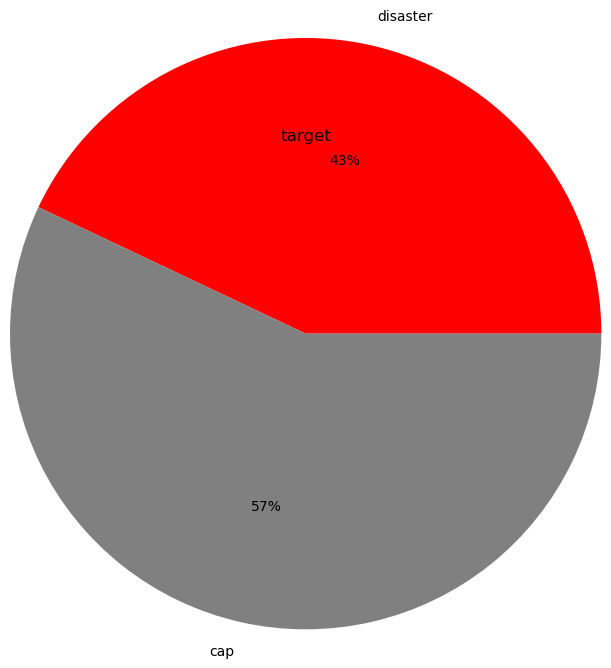

In [66]:

disaster=(((df['target']==1).sum())/len(df['target']))*100
cap=(((df['target']==0).sum())/len(df['target']))*100

x=[disaster,cap]

plt.pie(x,labels=['disaster','cap'],colors=['red','gray'],radius=2,autopct='%1.0f%%')
plt.title('target')
plt.show()

 The tweets in the data contain a lot of unecessary words including website links, usernames, and Twitter mentions. Getting rid of unecessary noise can help a model caputure patterns better. I segment the cleaning into three distinct functions to analyze the impact on the data at each step rather than combine all steps into one function. Ultimately, I want to remove noise while maintaining as much information within the data. 

#### 1. We begin by removing URLs:

In [67]:
# Function to remove URLs from text strings
def remove_urls(text):
    # Define a regular expression pattern to match URLs starting with "http" or "https"
    url_pattern = r'http[s]?://\S+'
    # Use re.sub() to replace matches of the pattern with an empty string
    cleaned_text = re.sub(url_pattern, '', text)
    return cleaned_text

# Apply the function to remove URLs from the 'text' column
df['cleaned_text'] = df['text'].apply(remove_urls)

print(df)



         id keyword location  \
0         1     NaN  Unknown   
1         4     NaN  Unknown   
2         5     NaN  Unknown   
3         6     NaN  Unknown   
4         7     NaN  Unknown   
...     ...     ...      ...   
7608  10869     NaN  Unknown   
7609  10870     NaN  Unknown   
7610  10871     NaN  Unknown   
7611  10872     NaN  Unknown   
7612  10873     NaN  Unknown   

                                                   text  target  \
0     Our Deeds are the Reason of this #earthquake M...       1   
1                Forest fire near La Ronge Sask. Canada       1   
2     All residents asked to 'shelter in place' are ...       1   
3     13,000 people receive #wildfires evacuation or...       1   
4     Just got sent this photo from Ruby #Alaska as ...       1   
...                                                 ...     ...   
7608  Two giant cranes holding a bridge collapse int...       1   
7609  @aria_ahrary @TheTawniest The out of control w...       1   
7610  M1.94 

#### 2. Stopwords are removed such as "the", "in", etc. 

In [68]:
# Download NLTK 
nltk.download('stopwords') 
nltk.download('punkt_tab')

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Function to remove stop words from text
def remove_stopwords(text):
    # Tokenize the text into words
    words = nltk.word_tokenize(text)
    # Remove stopwords and punctuation (keeping symbols)
    filtered_words = [word.lower() for word in words if (word.lower() not in stop_words) or (word in string.punctuation)]
    # Join the filtered words back into a sentence
    filtered_text = ' '.join(filtered_words)
    return filtered_text

# Apply the function to the 'text' column
df['cleaned_text2'] = df['cleaned_text'].apply(remove_stopwords)

# Print the original and cleaned text
print(df[['cleaned_text2', 'cleaned_text']])


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                          cleaned_text2  \
0        deeds reason # earthquake may allah forgive us   
1               forest fire near la ronge sask . canada   
2     residents asked 'shelter place ' notified offi...   
3     13,000 people receive # wildfires evacuation o...   
4     got sent photo ruby # alaska smoke # wildfires...   
...                                                 ...   
7608  two giant cranes holding bridge collapse nearb...   
7609  @ aria_ahrary @ thetawniest control wild fires...   
7610         m1.94 [ 01:04 utc ] ? 5km volcano hawaii .   
7611  police investigating e-bike collided car littl...   
7612  latest : homes razed northern california wildf...   

                                           cleaned_text  
0     Our Deeds are the Reason of this #earthquake M...  
1                Forest fire near La Ronge Sask. Canada  
2     All residents asked to 'shelter in place' are ...  
3     13,000 people receive #wildfires evacuation or...  
4

#### 3. Some of the tweets contain @ where Twitter usernames are provided. I get rid of any continous words following an @ symbol as usernames are not useful.

In [69]:
def remove_mentions(text):
    # Use regex to remove substrings starting with '@'
    cleaned_text = re.sub(r'@\w+', '', text)
    return cleaned_text.strip()  # Strip leading and trailing spaces

# Apply the function to the 'text' column
df['cleaned_text3'] = df['cleaned_text2'].apply(remove_mentions)
print(df['cleaned_text3'])

0          deeds reason # earthquake may allah forgive us
1                 forest fire near la ronge sask . canada
2       residents asked 'shelter place ' notified offi...
3       13,000 people receive # wildfires evacuation o...
4       got sent photo ruby # alaska smoke # wildfires...
                              ...                        
7608    two giant cranes holding bridge collapse nearb...
7609    @ aria_ahrary @ thetawniest control wild fires...
7610           m1.94 [ 01:04 utc ] ? 5km volcano hawaii .
7611    police investigating e-bike collided car littl...
7612    latest : homes razed northern california wildf...
Name: cleaned_text3, Length: 7613, dtype: object


#### I then create some graphs the visualize the data. Below is a histogram for the frequence of unique keywords. We can see that most keywords occur on average 35 times except for 'None' which is the placeholder for NaN values.

#### Also below is a graph showing the distribution of word length. We can see that the average tweet length is around 70 characters.

C:\Users\User\AppData\Local\Temp\ipykernel_8448\2078710354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='keyword', palette='viridis')


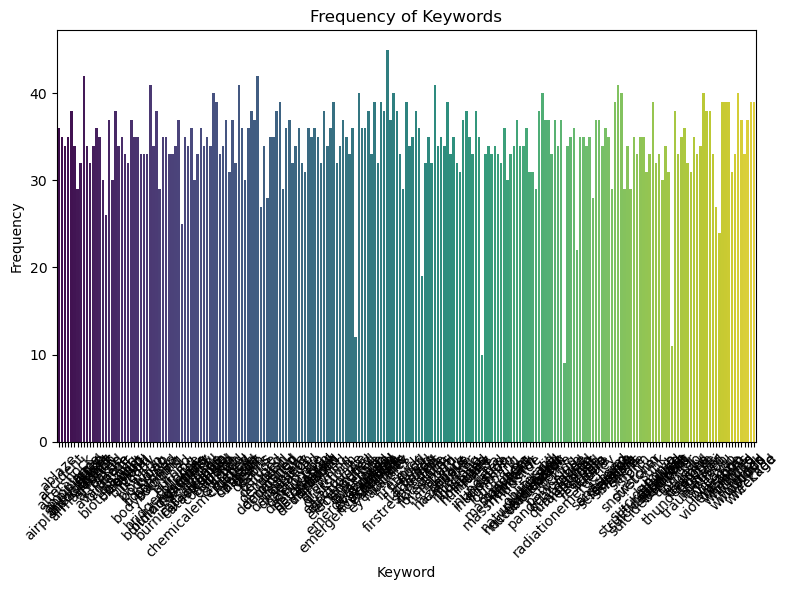

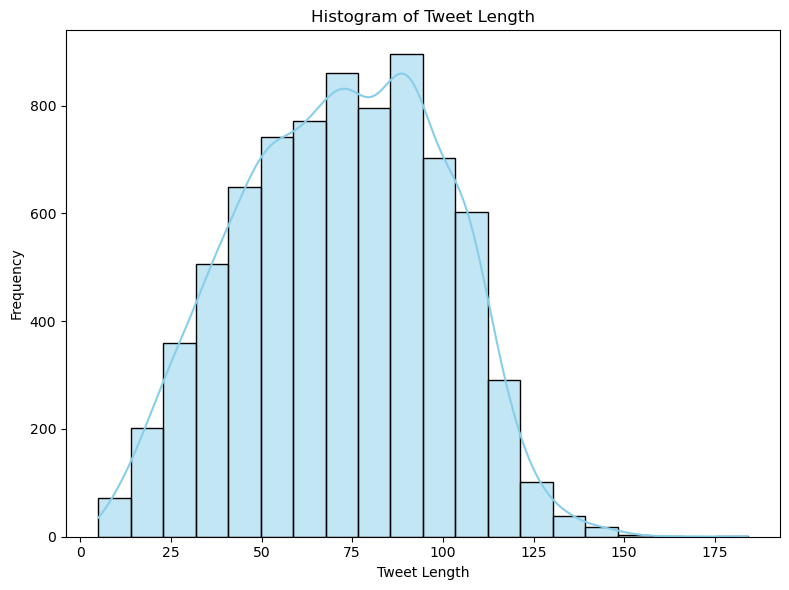

In [70]:

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='keyword', palette='viridis')
plt.title('Frequency of Keywords')
plt.xlabel('Keyword')
plt.ylabel('Frequency')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

# Histogram for tweet length
df['tweet_length'] = df['cleaned_text2'].apply(len)  # Calculate tweet length
plt.figure(figsize=(8, 6))
sns.histplot(df['tweet_length'], bins=20, color='skyblue', kde=True)
plt.title('Histogram of Tweet Length')
plt.xlabel('Tweet Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


## III. Expanding the Feature Space 

Now that the data is cleaned and I have a better idea of how the data is distributed I can make informed choices on creating features.

The keywords are important in identifying disasters. To include them into my model I started by identifying how many unique keywords were in the dataset. 

In [71]:
# Count the number of unique keyword types
num_unique_keywords = df['keyword'].nunique()
print("Number of different keyword types:", num_unique_keywords)


Number of different keyword types: 221


I turned every keyword into its own dummy variable creating 222 new columns of data. 

In [72]:
# Create dummy variables for each keyword
dummy_df = pd.get_dummies(df['keyword'], prefix='keyword')

# Concatenate the dummy variables with the original DataFrame
df_with_dummies = pd.concat([df, dummy_df], axis=1)

# Print the first few rows of the DataFrame with dummy variables
print(df_with_dummies.head())


   id keyword location                                               text  \
0   1     NaN  Unknown  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN  Unknown             Forest fire near La Ronge Sask. Canada   
2   5     NaN  Unknown  All residents asked to 'shelter in place' are ...   
3   6     NaN  Unknown  13,000 people receive #wildfires evacuation or...   
4   7     NaN  Unknown  Just got sent this photo from Ruby #Alaska as ...   

   target                                       cleaned_text  \
0       1  Our Deeds are the Reason of this #earthquake M...   
1       1             Forest fire near La Ronge Sask. Canada   
2       1  All residents asked to 'shelter in place' are ...   
3       1  13,000 people receive #wildfires evacuation or...   
4       1  Just got sent this photo from Ruby #Alaska as ...   

                                       cleaned_text2  \
0     deeds reason # earthquake may allah forgive us   
1            forest fire near la ronge s

#### Considering News Stations and Formality/Tone

I noticed that the dataset included tweets from news stations. These type of tweets were consistent with a target value of 1. This made me think that tweets that contained a more formal tone were more liklely refer to a real disaster. As a formal tone can also mean longer words so I incorporate length of tweet as a proxy to measure formality. 

Below I calculated the average length of tweet between the two target groups. We can see that disaster tweets had, on average, 77 characters while non disaster tweets had 67 characters. 

I used the average of these two numbers, 67, as a threshold to classify between a 'formal' and 'non-formal' tweet to create a formality dummy varaible.



Average length of characters for target=1: 76.85447875267502
Average length of characters for target=0: 68.13611239060342


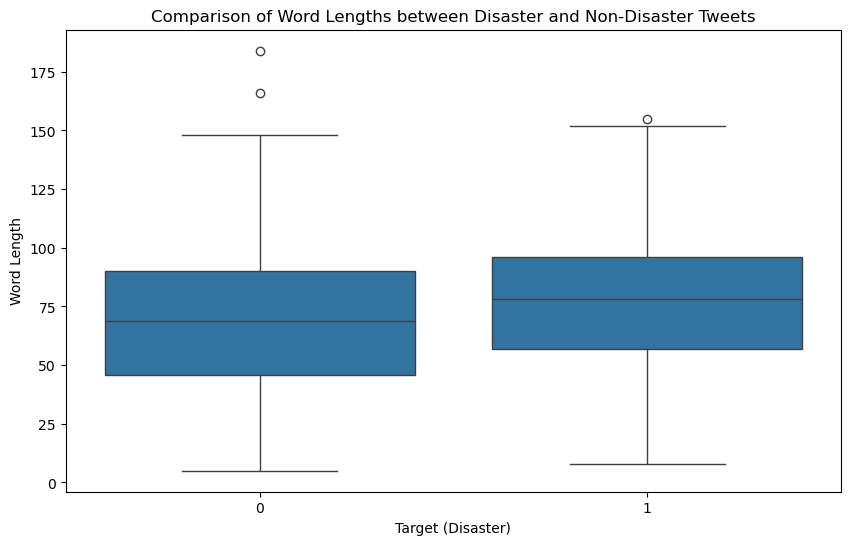

In [73]:
#Average Length
avg_length_target_1 = df[df['target'] == 1]['cleaned_text3'].str.len().mean()
avg_length_target_0 = df[df['target'] == 0]['cleaned_text3'].str.len().mean()

print("Average length of characters for target=1:", avg_length_target_1)
print("Average length of characters for target=0:", avg_length_target_0)

#PLot of word length boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='target', y='tweet_length')
plt.xlabel('Target (Disaster)')
plt.ylabel('Word Length')
plt.title('Comparison of Word Lengths between Disaster and Non-Disaster Tweets')
plt.show()

#Formality measure based on average
threshold_formal = 72

def classify_formality(row):
    if row['tweet_length'] > threshold_formal:
        return 'formal'
    else:
        return 'informal'

# Apply the classify_formality function to create the new feature
df['formality'] = df.apply(classify_formality, axis=1)
df = pd.get_dummies(df, columns=['formality'], prefix='formality_dummy')


#### Using #News as a source of truth

I also had noticed that tweets from New Stations were consistent with adding '#News' in the tweet. And since tweets from news stations were consistent with a target value of 1, I created a 'news' dummy variable where if the tweet had the word 'News' the value was 1 and 0 otherwise.

In [74]:
def check_news(tweet, target):
    if ('news' in tweet.lower()) and (target == 1):
        return 1
    else:
        return 0

# Apply the function to create the 'dummy_news' column
df['dummy_news'] = df.apply(lambda row: check_news(row['cleaned_text3'], row['target']), axis=1)



#### Accounting for Text Symbols

Other information in the tweets besides words are symbols such as exclamation marks and question marks. 

I checked to see if there a difference in the average number of symbols between the two target groups. We find that target tweets have less than 1/2 the amount of symbols in a tweet compared to non-target tweets. 

In [75]:

# Assuming you have a Data
def count_symbols(tweet):
    return sum(1 for char in tweet if char in ['?', '!'])

df['Symbol_Count'] = df['cleaned_text3'].apply(count_symbols)

# Calculate the average symbol count for target=1 and target=0
avg_symbol_count = df.groupby('target')['Symbol_Count'].mean()

print("Average number of symbols in tweets where target = 1:", avg_symbol_count[1])
print("Average number of symbols in tweets where target = 0:", avg_symbol_count[0]) 


Average number of symbols in tweets where target = 1: 0.3335371446040966
Average number of symbols in tweets where target = 0: 0.7383694150161216


I then create a box plot to visually see the symbol count for each target group. We see that the box plots are consistent with the average values calculated above, however we see that there are many outliers. 

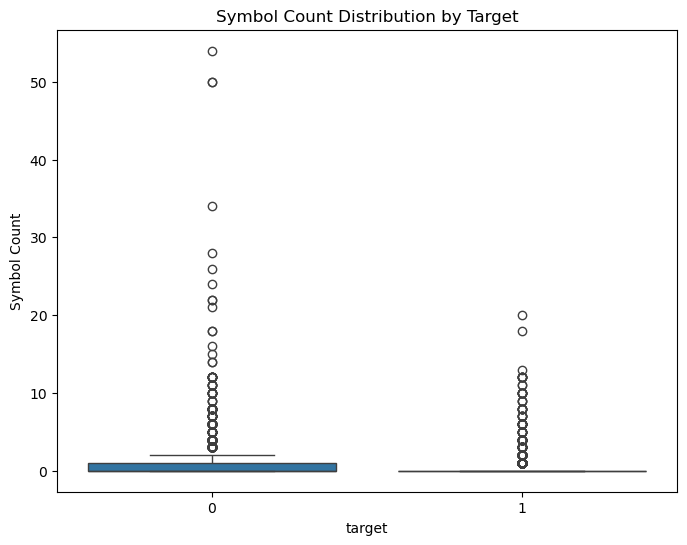

In [76]:

# Create a box plot using seaborn
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='Symbol_Count', data=df)

# Add labels and title
plt.xlabel('target')
plt.ylabel('Symbol Count')
plt.title('Symbol Count Distribution by Target')

# Show the plot
plt.show()


Out of curiosity, I display the tweet that has the most amount of symbols.

In [77]:
# Find the index of the row with the maximum symbol count
max_symbol_index = df['Symbol_Count'].idxmax()

# Get the text with the most symbols
text_with_most_symbols = df.loc[max_symbol_index, 'cleaned_text3']

# Display the text
print("Text with the most symbols:\n", text_with_most_symbols)


Text with the most symbols:
 _ ? ? ? ? ? retweet ? ? ? ? ? ? ? ? ? ? ? ? follow rt ? ? ? ? ? ? ? ? ? ? ? ? followback ? ? ? ? ? ? ? ? ? ? ? ? gain ? ? ? ? ? ? ? ? ? ? ? ? follow ? @ ganseyman # rt_4_a_mention # ty


#### Standardizing Location 

The location data is very inconsistent. The location column is supposed to represent where the tweet was sent, but a random sample of 10 observations show how messy the data is.

We can see that the location data has useless information such as an email, and locations of various levels.

In [78]:

# Randomly select 5 values from the 'location' column
random_locations = df['location'].sample(10)

# Print the randomly selected location values
print(random_locations)


4805                           Unknown
1876                         w. Nykae 
378                            Unknown
869                            Unknown
604                   Over the Moon...
5275          Financial News and Views
592                                 US
3417                        Whitby, ON
5790    A little house in the outback.
1215          somewhere over a rainbow
Name: location, dtype: object


However since there are real locations within the data, I use Spacy to extract geophraphical cities. I then turn each city into its own dummy variable in the event there are duplicates. 

In [79]:

# Load English language model in spaCy
nlp = spacy.load("en_core_web_sm")

def extract_city_ner(location):
    if not isinstance(location, str):
        return None
    doc = nlp(location)
    city_names = [ent.text for ent in doc.ents if ent.label_ == 'GPE']  # GPE: Geopolitical Entity
    return city_names[0] if city_names else None


df['cities'] = df['location'].apply(extract_city_ner)

# Create dummy variables for each unique city
city_dummies = pd.get_dummies(df['cities'], prefix='city')

# Concatenate dummy variables with original DataFrame
df = pd.concat([df, city_dummies], axis=1)


## IV. Models 

Now that my data is cleaned and I have expanded the feature space I begin building models to classify the tweets.

#### Neural Network (without scaling)

We begin with an NLP approach employing LSTM Neural Network. Note that because we predict using text data, the featured dummies will not be used. Only our text cleaning efforts will be reflected. 
Since all of my data falls within the range of [0,1], the benefit of scaling the data is unclear. To test if it helps my model I build two LSTM Nueral Networks, one with scaled and non-scaled data. 

I begin by defining my X and Y matrices.

In [80]:

X=df.drop(['target','cleaned_text','location','text','cities','cleaned_text2','formality_dummy_informal','id','location','keyword','tweet_length'],axis=1) 
y=df['target']

Since my data is in text, it has to be tokenized first.

In [81]:
#Tokenization
tokenizer = Tokenizer(num_words=1000, oov_token='<OOV>')
tokenizer.fit_on_texts(X['cleaned_text3'])
sequences = tokenizer.texts_to_sequences(X['cleaned_text3'])
padded_sequences = pad_sequences(sequences, maxlen=100) 

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y, test_size=0.2, random_state=42)

# Build the RNN model
model = Sequential()
model.add(Embedding(input_dim=1000, output_dim=100, input_length=100))
model.add(SpatialDropout1D(0.5))
model.add(LSTM(100, dropout=0.5))
model.add(Dense(1, activation='sigmoid')) 

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


Epoch 1/10


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.6502 - loss: 0.6145 - val_accuracy: 0.7603 - val_loss: 0.5078
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.7819 - loss: 0.4688 - val_accuracy: 0.7689 - val_loss: 0.4765
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.8094 - loss: 0.4282 - val_accuracy: 0.7722 - val_loss: 0.4774
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.8238 - loss: 0.4052 - val_accuracy: 0.7722 - val_loss: 0.4884
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.8291 - loss: 0.3913 - val_accuracy: 0.7722 - val_loss: 0.4966
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.8320 - loss: 0.3875 - val_accuracy: 0.7748 - val_loss: 0.4955
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.8386 - loss: 0.3794 - val_accuracy: 0.7689 - val_loss: 0.5101
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.8369 - loss: 0.3748 - val_accurac

The model's accuracy of 0.76 indicates that it correctly predicts the target variable for approximately 76% of the instances in the dataset. This suggests that the model is learning some patterns in the data, but it may not be capturing all the complexities or variations present in the dataset


#### Neural Network with Scaling

For the neural network model with scaled data, I started by defining my X and Y.

In [82]:
X=df.drop(['target','cleaned_text','location','text','cities','cleaned_text2','formality_dummy_informal','id','location','keyword','tweet_length'],axis=1) 
y=df['target'] 


In [83]:
tokenizer = Tokenizer(num_words=1000, oov_token='<OOV>')
tokenizer.fit_on_texts(X['cleaned_text3'])
sequences = tokenizer.texts_to_sequences(X['cleaned_text3'])
padded_sequences = pad_sequences(sequences, maxlen=100)  # Adjust maxlen as needed

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y, test_size=0.2, random_state=42)
min_max_scaler = MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)
# Build the RNN model
model = Sequential()
model.add(Embedding(input_dim=1000, output_dim=100, input_length=100))
model.add(SpatialDropout1D(0.5))
model.add(LSTM(100, dropout=0.5))
model.add(Dense(1, activation='sigmoid'))  # Adjust activation based on your task

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


Epoch 1/10


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


191/191 ━━━━━━━━━━━━━━━━━━━━ 25s 113ms/step - accuracy: 0.5673 - loss: 0.6862 - val_accuracy: 0.5739 - val_loss: 0.6825
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.5693 - loss: 0.6849 - val_accuracy: 0.5739 - val_loss: 0.6823
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.5695 - loss: 0.6846 - val_accuracy: 0.5739 - val_loss: 0.6825
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.5695 - loss: 0.6849 - val_accuracy: 0.5739 - val_loss: 0.6823
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.5695 - loss: 0.6843 - val_accuracy: 0.5739 - val_loss: 0.6826
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 95ms/step - accuracy: 0.5695 - loss: 0.6840 - val_accuracy: 0.5739 - val_loss: 0.6822
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.5695 - loss: 0.6839 - val_accuracy: 0.5739 - val_loss: 0.6827
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step - accuracy: 0.5695 - loss: 0.6836 - val_accur

The model's accuracy of 0.57 indicates that it correctly predicts the target variable for approximately 57% of the instances in the dataset. This suggest the model performs no better than guessing, since 57% is the assumed proportion of disasters in the population.

#### Logistic Regression 

I now try a logistic regression model. This model is limited on capturing non-linear patterns. Since the data is text, I used countvectorizer to split the text into tokens, to which these numbers can used in the model. I also include the featured dummies from earlier.

In [84]:

vectorizer = CountVectorizer()

X_text = vectorizer.fit_transform(df['cleaned_text3'])

df_text_bow = pd.DataFrame(X_text.toarray(), columns=vectorizer.get_feature_names_out())

df_combined = pd.concat([df, df_text_bow], axis=1)


After vectorizing, we have almost 18000 features which may lead to overfitting. 

For the logisitic regression,  I define my X and Y space.

In [85]:
#drop unnecessary columns
x=df_combined.drop(['target','cleaned_text','cleaned_text3','location','text','cities','cleaned_text2','formality_dummy_informal','id','location','keyword','tweet_length'],axis=1) 
y=df['target'] 
x_list = x.columns
print('Features include', x_list)

Features include Index(['formality_dummy_formal', 'dummy_news', 'Symbol_Count',
       'city_@protectingtitan', 'city_AB', 'city_AL', 'city_ATLANTA',
       'city_Abuja, Nigeria', 'city_Abuja,Nigeria', 'city_Afghanistan',
       ...
       'ûò', 'ûò800000', 'ûòthe', 'ûòåêcnbc', 'ûó', 'ûóher', 'ûókody',
       'ûónegligence', 'ûótech', 'ûówe'],
      dtype='object', length=17803)


The data is split into training and test groups. 

I also use the results to graph a boxplot to visualize the predictions.

<Axes: xlabel='target'>

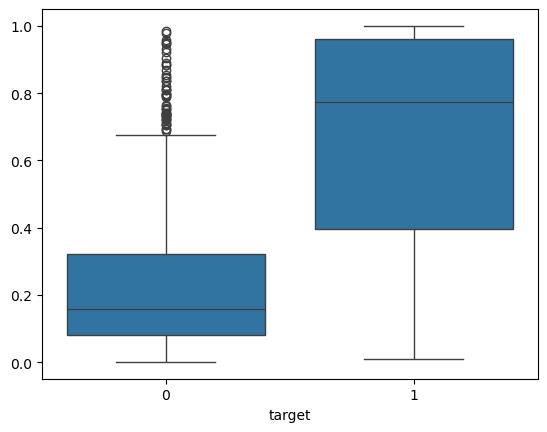

In [86]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state = 1)

lm = LogisticRegression(max_iter=5000)
lm.fit(x_train, y_train)
#Predict accurary of disaster
y_probs = lm.predict_proba(x_test) 
sns.boxplot(x=y_test, y=y_probs[:,1])


We can see that the logistic regression model can clearly distinguish the difference between a target and non-target tweet. 

I compute a confusion matrix to formally see results.

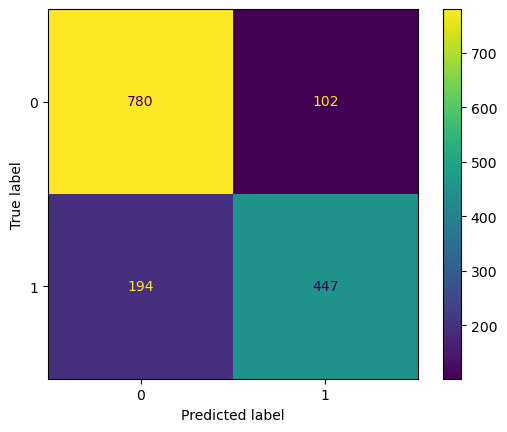

In [87]:
#Performance Metrics
y_pred = lm.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lm.classes_)
disp.plot()

Our confusion matrix tells use that the logistic regression model predicts non-disaster tweets better than disaster tweets. This is most likely due to the data being unbalanced.

Below is the code for the corresponding precision-recall curve. It has a balanced shape that indicates a healthy trade off between the two metrics. We can see that precision maintains 80% until recall reaches 75%.

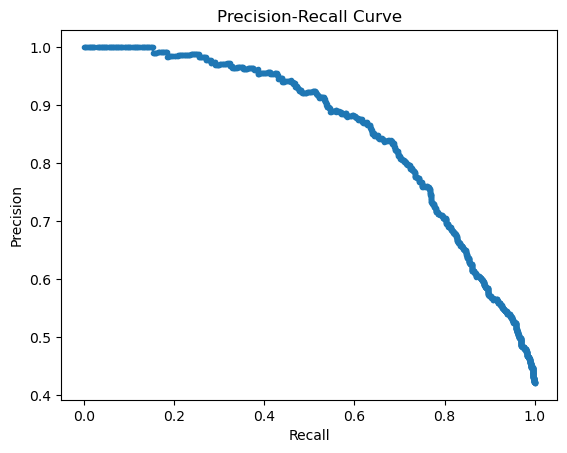

In [88]:
#Performance Metrics
precision, recall, thresholds = precision_recall_curve(y_test, y_probs[:, 1])

plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

Classifier Metrics are computed:

We can see that at an Accuracy of 0.8, the logistic regression outperforms nueral network by around 3%. 

In [89]:
#Performance Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1) 


Accuracy: 0.8056467498358503
Precision: 0.8142076502732241
Recall: 0.6973478939157566
F1 Score: 0.7512605042016807


#### Random Forest

We now try a Random Forest Model. We use the same vectorized data for this model.

In [90]:
#RF Model
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(x_train, y_train)

# Make predictions on the testing data
y_pred = rf_classifier.predict(x_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print(accuracy)
print(report) 

0.7872619829284307
              precision    recall  f1-score   support

           0       0.76      0.91      0.83       874
           1       0.84      0.62      0.71       649

    accuracy                           0.79      1523
   macro avg       0.80      0.77      0.77      1523
weighted avg       0.79      0.79      0.78      1523



At an accuracy of 0.79, it barely underperforms the logistic regression model by 1%. 

## V. Conclusion
This project explored whether tweet language alone can reliably identify real disaster events. After cleaning the text and engineering features around formality, keywords, symbol usage, and geography, three models were tested: an LSTM Neural Network, Logistic Regression, and Random Forest.
The Logistic Regression was the best performing model at 80% accuracy, outperforming both the Random Forest (79%) and the LSTM (77%). The LSTM's lower performance is likely due to the relatively small dataset size — deep learning models typically require far more data to outperform classical methods. Notably, the LSTM only consumed the raw tweet text while the Logistic Regression and Random Forest had access to the full engineered feature set, which may also explain part of the gap.
The confusion matrix revealed the model predicts non-disaster tweets more reliably than disaster tweets, which is consistent with the class imbalance in the dataset (57% non-disaster). Addressing this imbalance through techniques like oversampling or class weighting would be a natural next step to improve recall on the disaster class.